# Resting-State EEG: Grouped Feature Extraction and Visualization

This is stage two. From the harmonized 49-channel checkpoints of notebook 01 it extracts **836 features**
in eight families and visualizes each family in its own section. Groups B, C, F and G are computed with
the standard neuroscience packages (`fooof`/specparam, `pycrostates`, `mne-connectivity`), so every value
matches the canonical definition its column name states.

| Family | Content | Count |
|--------|---------|------:|
| A spectral | multitaper band power (absolute, relative), ratios, asymmetry | 168 |
| B alpha peak | FOOOF periodic alpha: centre frequency, power, bandwidth | 33 |
| C aperiodic | FOOOF 1/f exponent and offset | 22 |
| D entropy | sample, permutation, spectral, Lempel-Ziv | 44 |
| E fractal | Higuchi dimension, detrended fluctuation exponent | 22 |
| F microstates | pycrostates Koenig A-D dynamics | 32 |
| G connectivity | debiased wPLI^2 between 10 regions | 225 |
| H graph | density-thresholded graph metrics | 290 |

**Interpretation rules.** The features are cortical sensor-space summaries; they are not source-localized
and make no diagnosis. The group figures contrast Control and Psychosis descriptively; they are not a
classifier. Every value is also expressed as an age/sex control-referenced z-score for interpretability.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

DATASET_ROOT = Path.cwd()
if DATASET_ROOT.name == "notebooks":
    DATASET_ROOT = DATASET_ROOT.parent
sys.path.insert(0, str(DATASET_ROOT))

from utils import config as C, viz as V
from utils.features import build_schema
groups, names = build_schema()
tables = V.load_tables()
tables["qc"] = V._qc_frame()
chan = V.build_channel_summary()          # cached per-channel spectral summary
FIG = C.FIGURE_ROOT / "cohort"; FIG.mkdir(parents=True, exist_ok=True)
def show_save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()
print(f"feature matrix: {tables['eeg'].shape[0]} recordings x {len(names)} features")
print("families:", {k: len(v) for k, v in groups.items()})

/Users/stijnvanseveren/PROJECTS/summer_2026/NEUROHACKADEMY/compass_engine/validation/datasets/PSYCHOSIS_FIRST_EPISODE/utils/features.py:37: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


feature matrix: 143 recordings x 836 features
families: {'A_spectral': 168, 'B_alpha_peak': 33, 'C_aperiodic': 22, 'D_entropy': 44, 'E_fractal': 22, 'F_microstates': 32, 'G_connectivity': 225, 'H_graph': 290}


## 1. Schema and completeness

Every recording carries the same 836 columns in a fixed order. Eligible recordings are complete except
where a measure is genuinely not estimable (most often a frequency band whose sparse phase coupling
cannot form a connected graph, leaving that band's Family H values missing). Ineligible recordings keep
the schema with empty feature cells.

recordings: 143 | finite cells: 110,229 / 119,548 (92.2%)
feature-eligible recordings: 134 | all-empty (ineligible) rows: 9


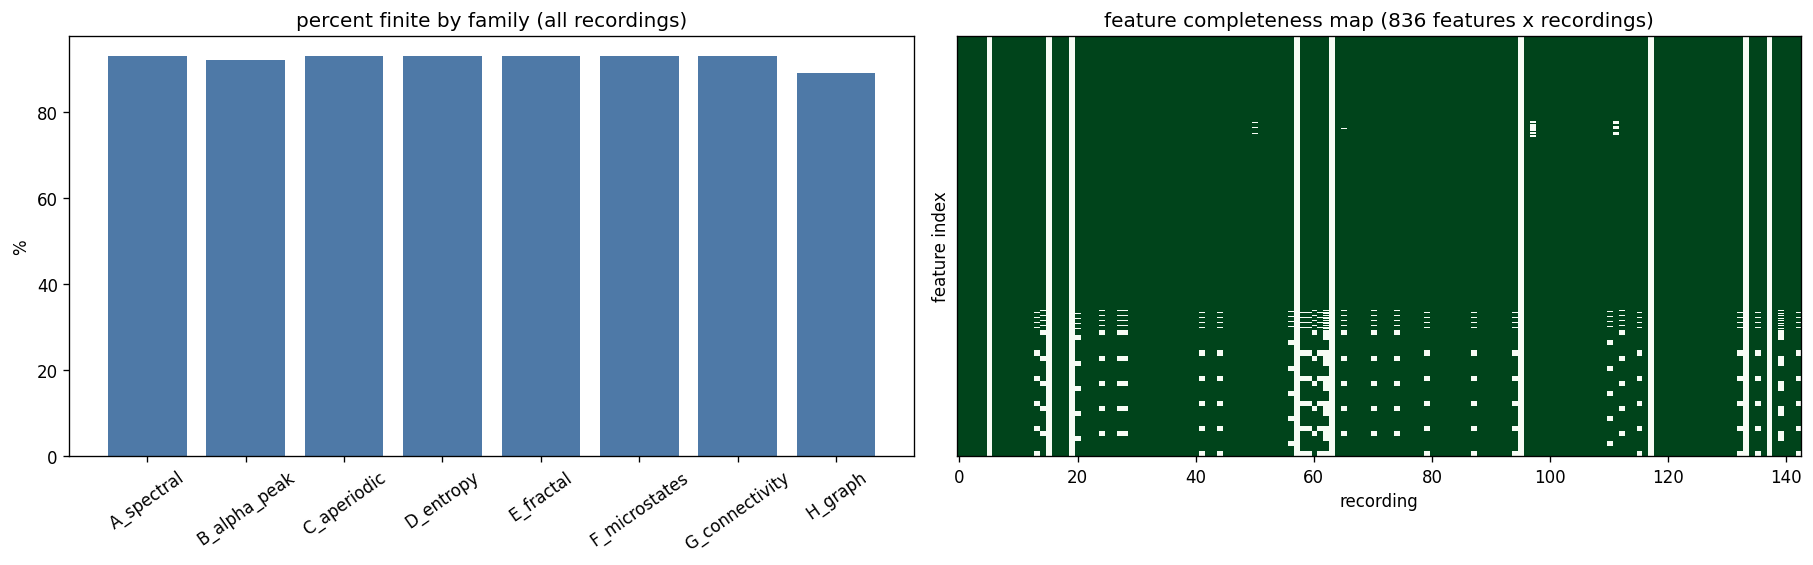

In [2]:
eeg = tables["eeg"]; vals = eeg[names].apply(pd.to_numeric, errors="coerce")
finite = np.isfinite(vals.to_numpy())
elig = tables["qc"].set_index("recording_id")["feature_eligible"]
per_group = {g: int(np.isfinite(vals[cols].to_numpy()).mean()*100) for g, cols in groups.items()}
print(f"recordings: {len(eeg)} | finite cells: {finite.sum():,} / {finite.size:,} "
      f"({100*finite.mean():.1f}%)")
print(f"feature-eligible recordings: {int(elig.sum())} | all-empty (ineligible) rows: "
      f"{int((vals.notna().sum(1)==0).sum())}")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), constrained_layout=True)
ax[0].bar(per_group.keys(), per_group.values(), color="#4e79a7")
ax[0].set_title("percent finite by family (all recordings)"); ax[0].set_ylabel("%")
ax[0].tick_params(axis="x", rotation=35)
order = eeg["recording_id"].tolist()
completeness = vals.notna().astype(int).to_numpy()
ax[1].imshow(completeness.T, aspect="auto", cmap="Greens", interpolation="nearest")
ax[1].set_title("feature completeness map (836 features x recordings)")
ax[1].set_xlabel("recording"); ax[1].set_ylabel("feature index"); ax[1].set_yticks([])
show_save(fig, "00_completeness")

## 2. Interpretable values: raw and control-referenced z-scores

Each feature is delivered twice: the raw value (`results/eeg_features.csv`) and an age/sex
control-referenced z-score (`results/eeg_features_zscores.csv`). Within each dataset the control group is
regressed on centred age and sex, and each subject's residual is divided by the control residual standard
deviation. A z of +1 means one control-standard-deviation above a same-age, same-sex control.

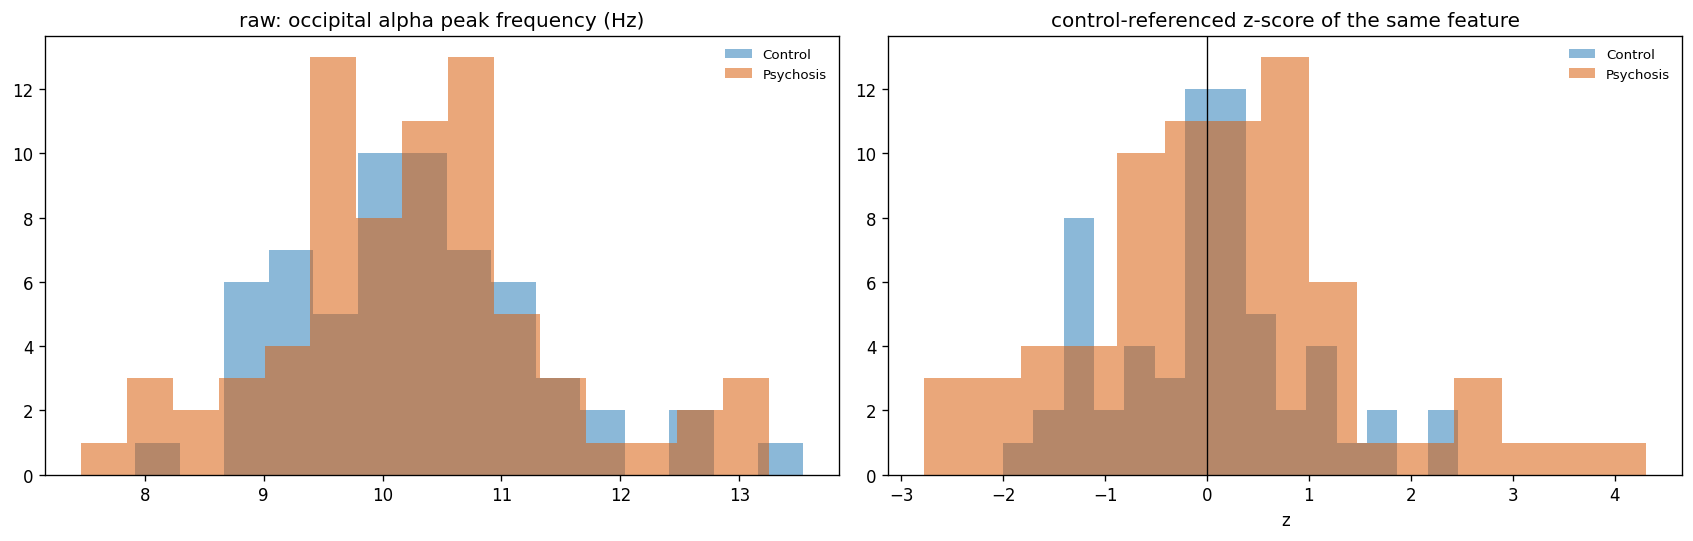

z-score table: (143, 837) | example feature: B_alpha_peak__center_frequency_hz__occipital_left


In [3]:
z = tables["z"]; zcols = [c for c in z.columns if c.startswith("Z_control__")]
example = "B_alpha_peak__center_frequency_hz__occipital_left"
raw_vals = tables["merged"][["group", example]].dropna()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), constrained_layout=True)
for g, c in V.GROUP_COLORS.items():
    ax[0].hist(raw_vals.loc[raw_vals["group"]==g, example], bins=15, alpha=0.55, color=c, label=g)
ax[0].set_title("raw: occipital alpha peak frequency (Hz)"); ax[0].legend(frameon=False, fontsize=8)
zc = "Z_control__" + example
zmerge = z[["recording_id", zc]].merge(tables["meta"][["recording_id","group"]], on="recording_id")
for g, c in V.GROUP_COLORS.items():
    ax[1].hist(zmerge.loc[zmerge["group"]==g, zc].dropna(), bins=15, alpha=0.55, color=c, label=g)
ax[1].axvline(0, color="k", lw=0.8)
ax[1].set_title("control-referenced z-score of the same feature"); ax[1].set_xlabel("z"); ax[1].legend(frameon=False, fontsize=8)
show_save(fig, "00_zscore_example")
print("z-score table:", z.shape, "| example feature:", example)

## 3. Family A - Spectral power (168)

Multitaper power spectral density over five bands (delta 1-4, theta 4-8, alpha 8-13, beta 13-30, low
gamma 30-45 Hz). For each band and each of the eleven scopes we report `log10_absolute_power_uv2` and
`relative_power_fraction_of_1_45_hz`; plus three `natural_log_power_ratio` measures (theta/alpha,
theta/beta, alpha/delta) and a `log10_power_asymmetry_right_minus_left` per region. The topographies below
are group-mean relative power; the healthy posterior alpha maximum is the dominant resting feature.

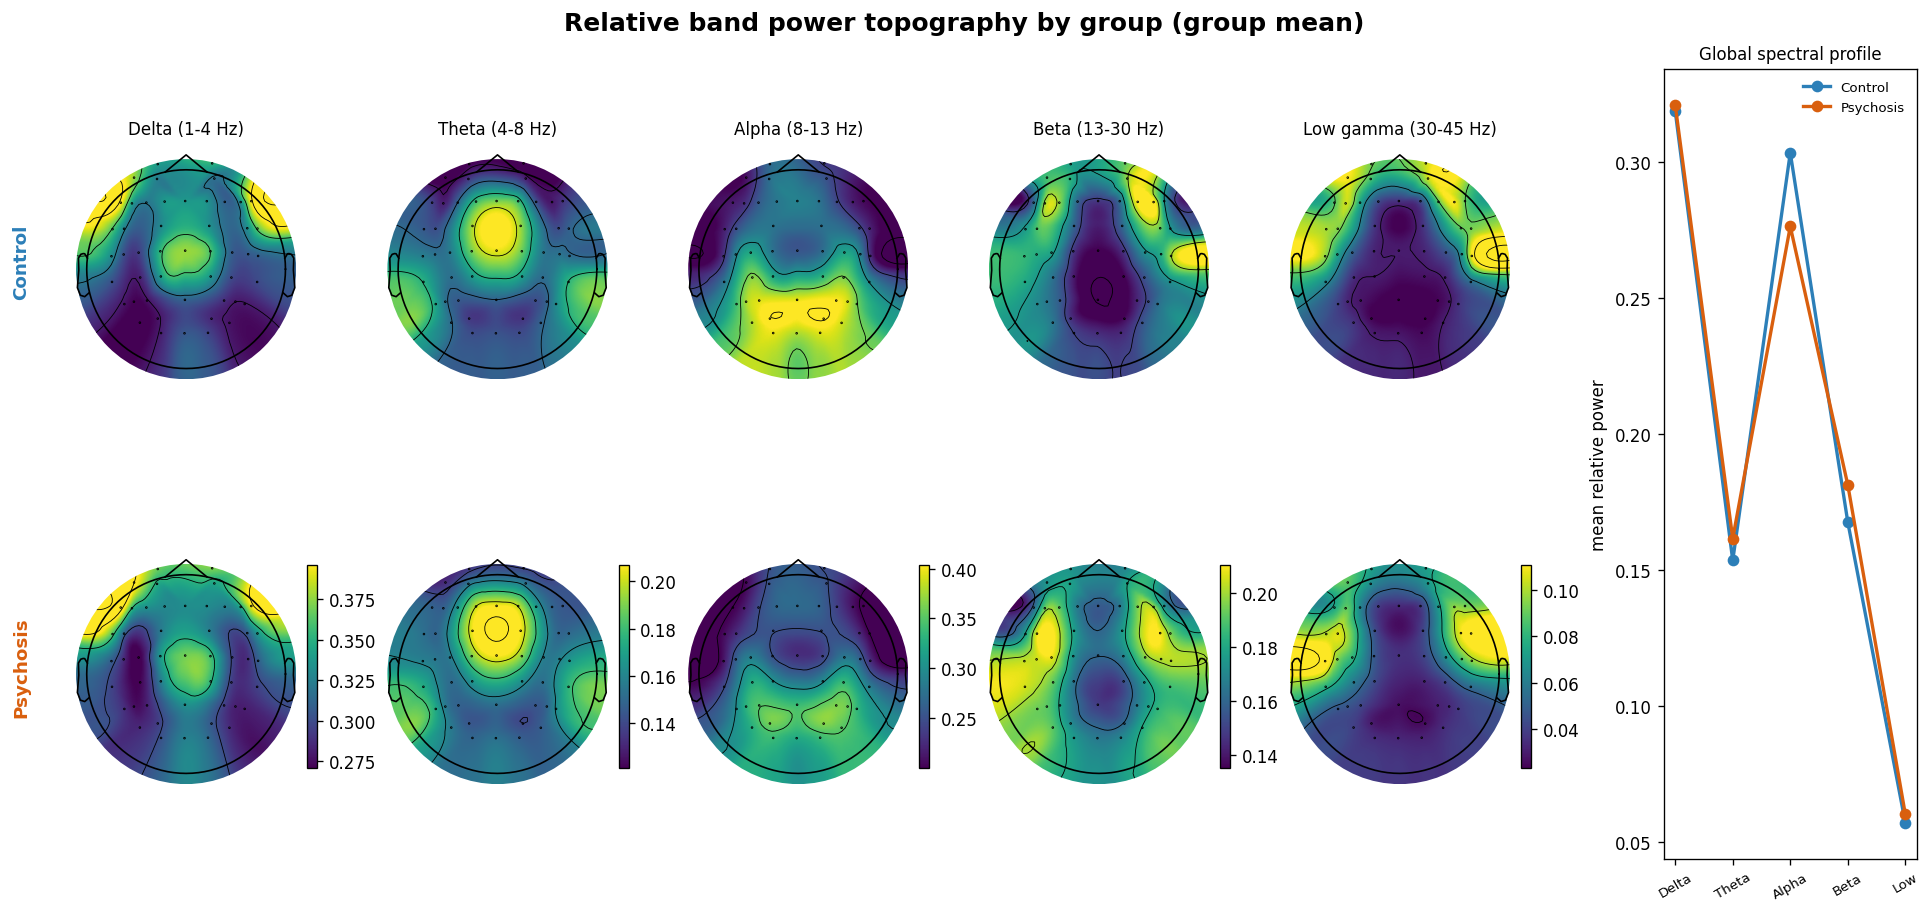

In [4]:
fig = V.fig_spectral_topography(tables, chan)
show_save(fig, "01_spectral_topography")

## 4. Family B - Alpha peak (33) and Family C - Aperiodic 1/f (22)

FOOOF parameterizes each channel spectrum into an aperiodic 1/f component and Gaussian peaks. Family B
takes the strongest periodic peak in 7-14 Hz as the alpha peak (`center_frequency_hz`,
`power_log10_uv2_above_aperiodic`, `bandwidth_hz`). Family C reports the aperiodic `exponent` (spectral
slope, steeper with more inhibition/aperiodic activity) and `offset_log10_uv2`. Both replace the previous
bespoke fits with the canonical spectral-parameterization model.

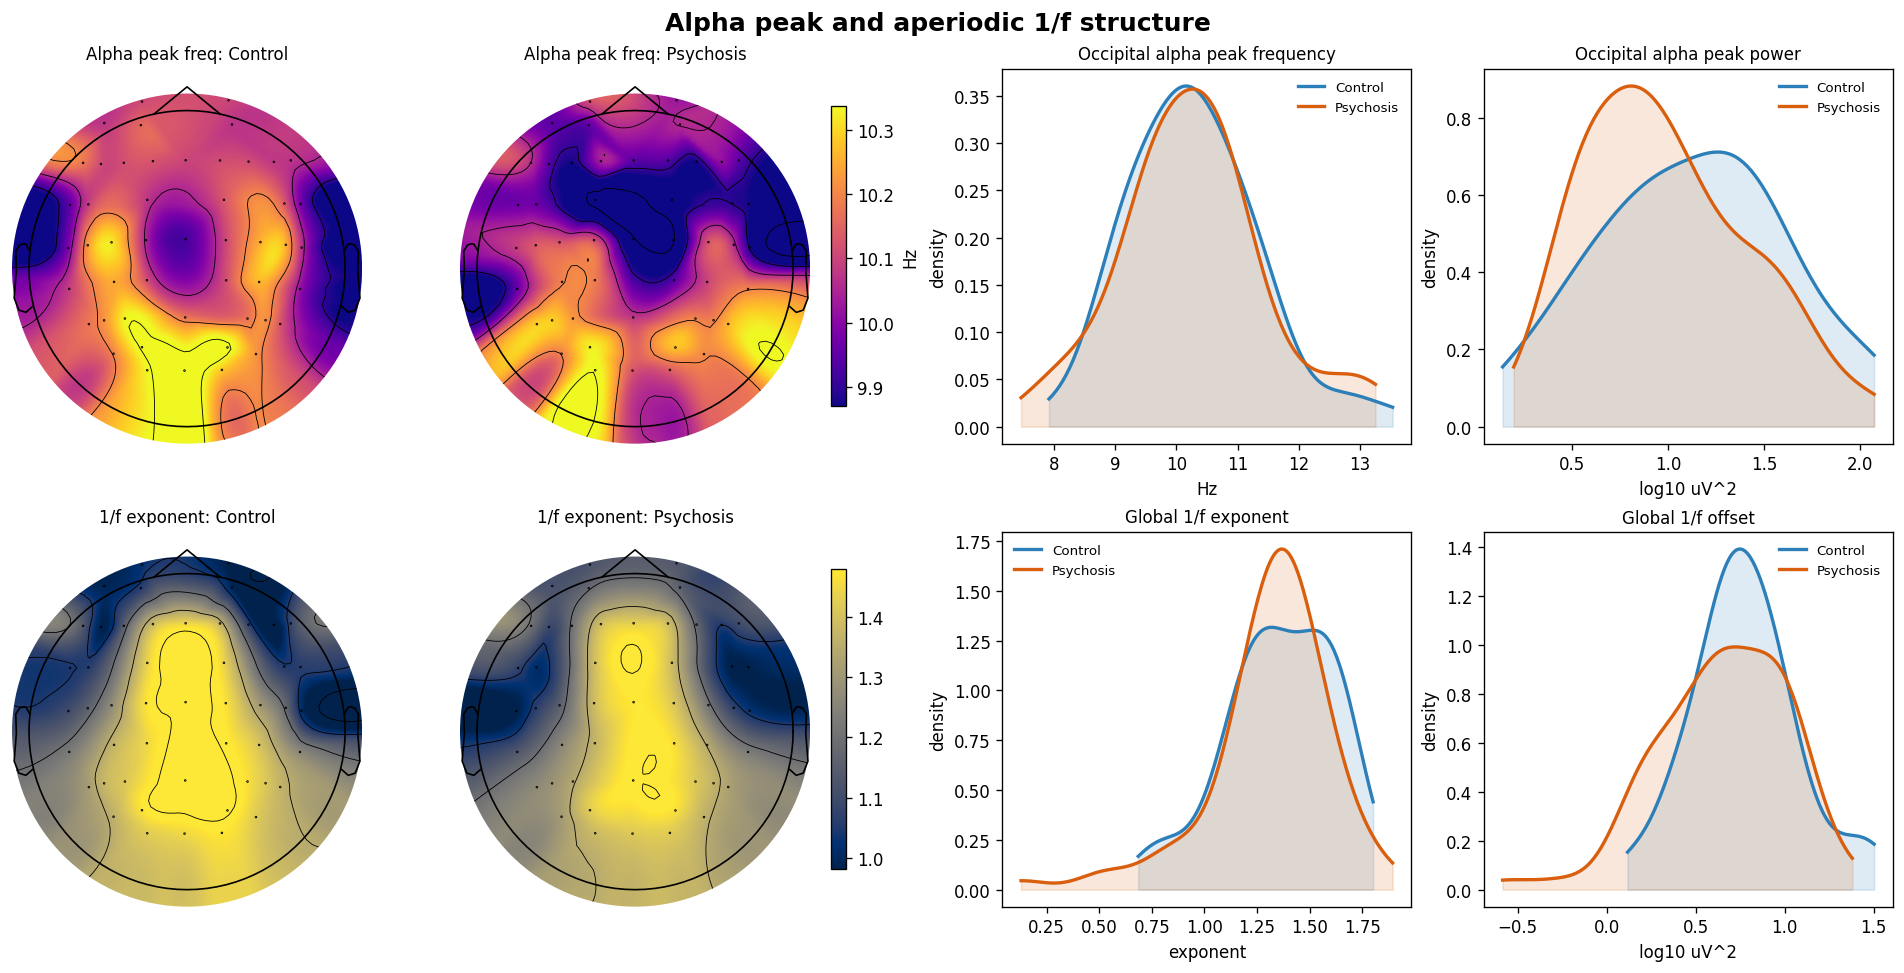

In [5]:
fig = V.fig_alpha_aperiodic(tables, chan)
show_save(fig, "02_alpha_aperiodic")

## 5. Family D - Entropy (44) and Family E - Fractal (22)

Signal-complexity measures from `antropy`, per scope: sample entropy, normalized permutation entropy,
normalized spectral entropy, and normalized Lempel-Ziv complexity (Family D); Higuchi fractal dimension
and the detrended-fluctuation (long-range temporal correlation) exponent (Family E). Higher entropy and
complexity reflect less predictable, richer dynamics.

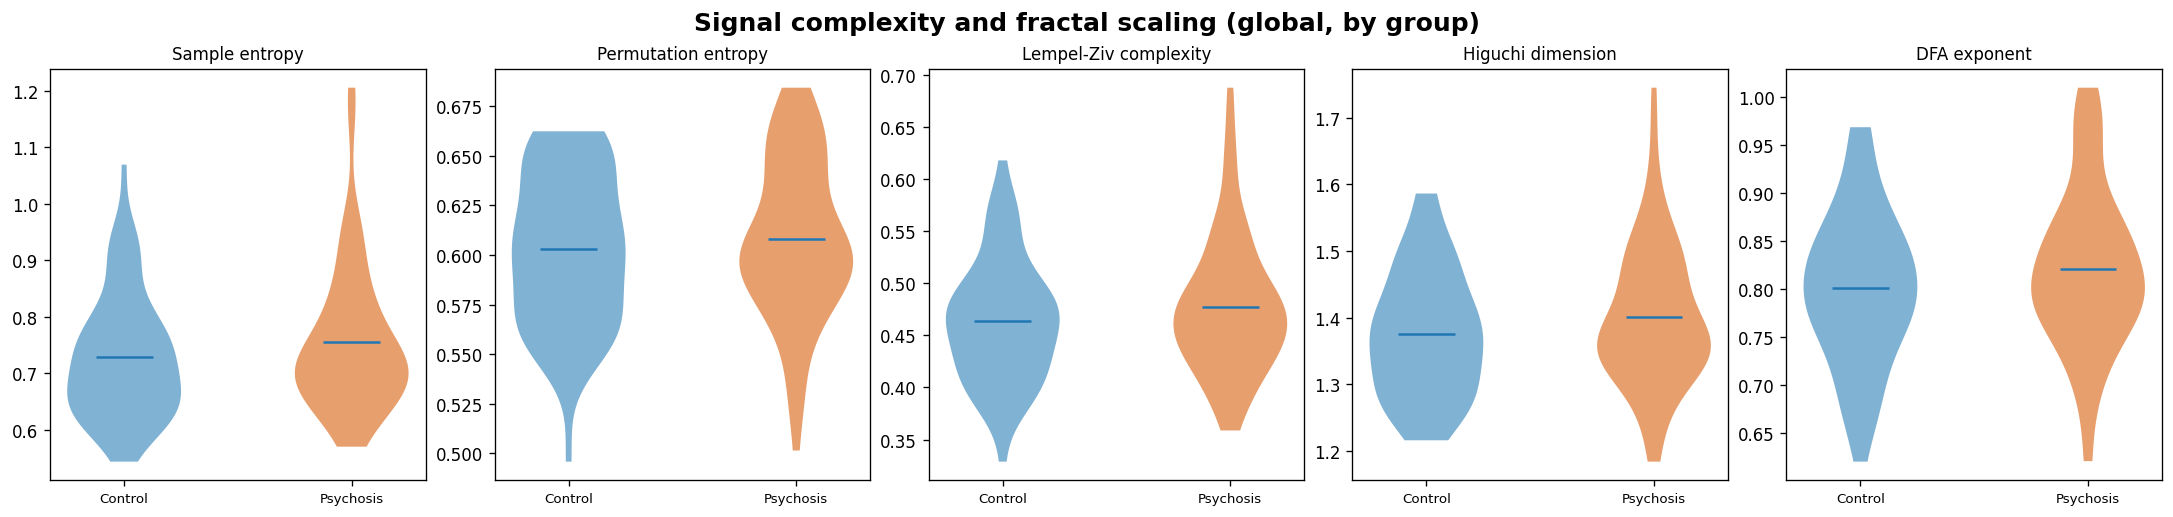

In [6]:
fig = V.fig_complexity(tables)
show_save(fig, "03_complexity")

## 6. Family F - Microstates (32)

`pycrostates` fits four modified-K-means templates on GFP-peak topographies pooled across all eligible
subjects, relabelled to the canonical Koenig A-D scheme by topographic orientation, then back-fits each
recording. We report per class `mean_duration_ms`, `coverage_fraction`, `occurrence_per_second` and
`global_explained_variance_fraction`; the 12 ordered transition probabilities; and global GEV, transition
entropy, sequence complexity, and mean global field power. The four template maps and their group
dynamics are shown below.

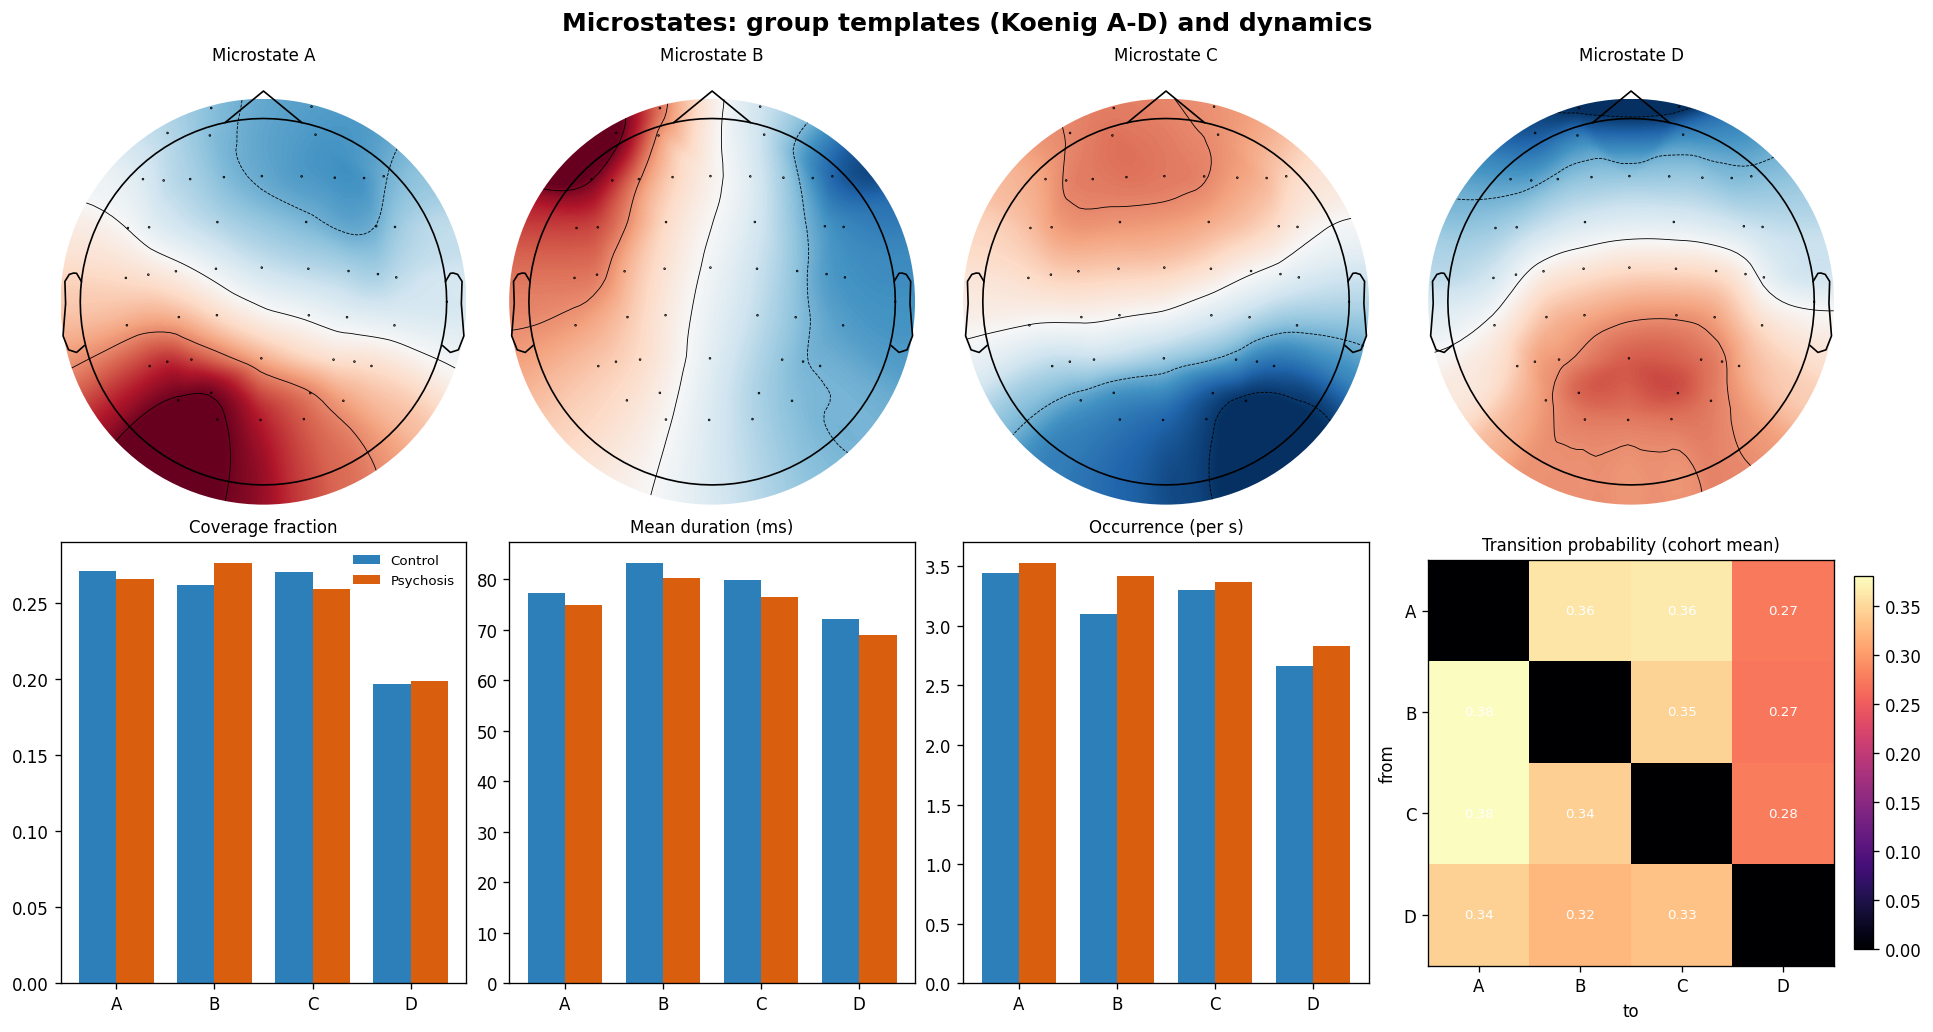

In [7]:
fig = V.fig_microstates(tables)
show_save(fig, "04_microstates")

## 7. Family G - Functional connectivity (225)

Debiased weighted phase-lag index squared (`mne-connectivity`, multitaper) between the ten region nodes,
per band, for all 45 region pairs. wPLI is insensitive to zero-lag volume conduction, so it reflects
genuine phase coupling. The matrices below are group-mean connectivity per band.

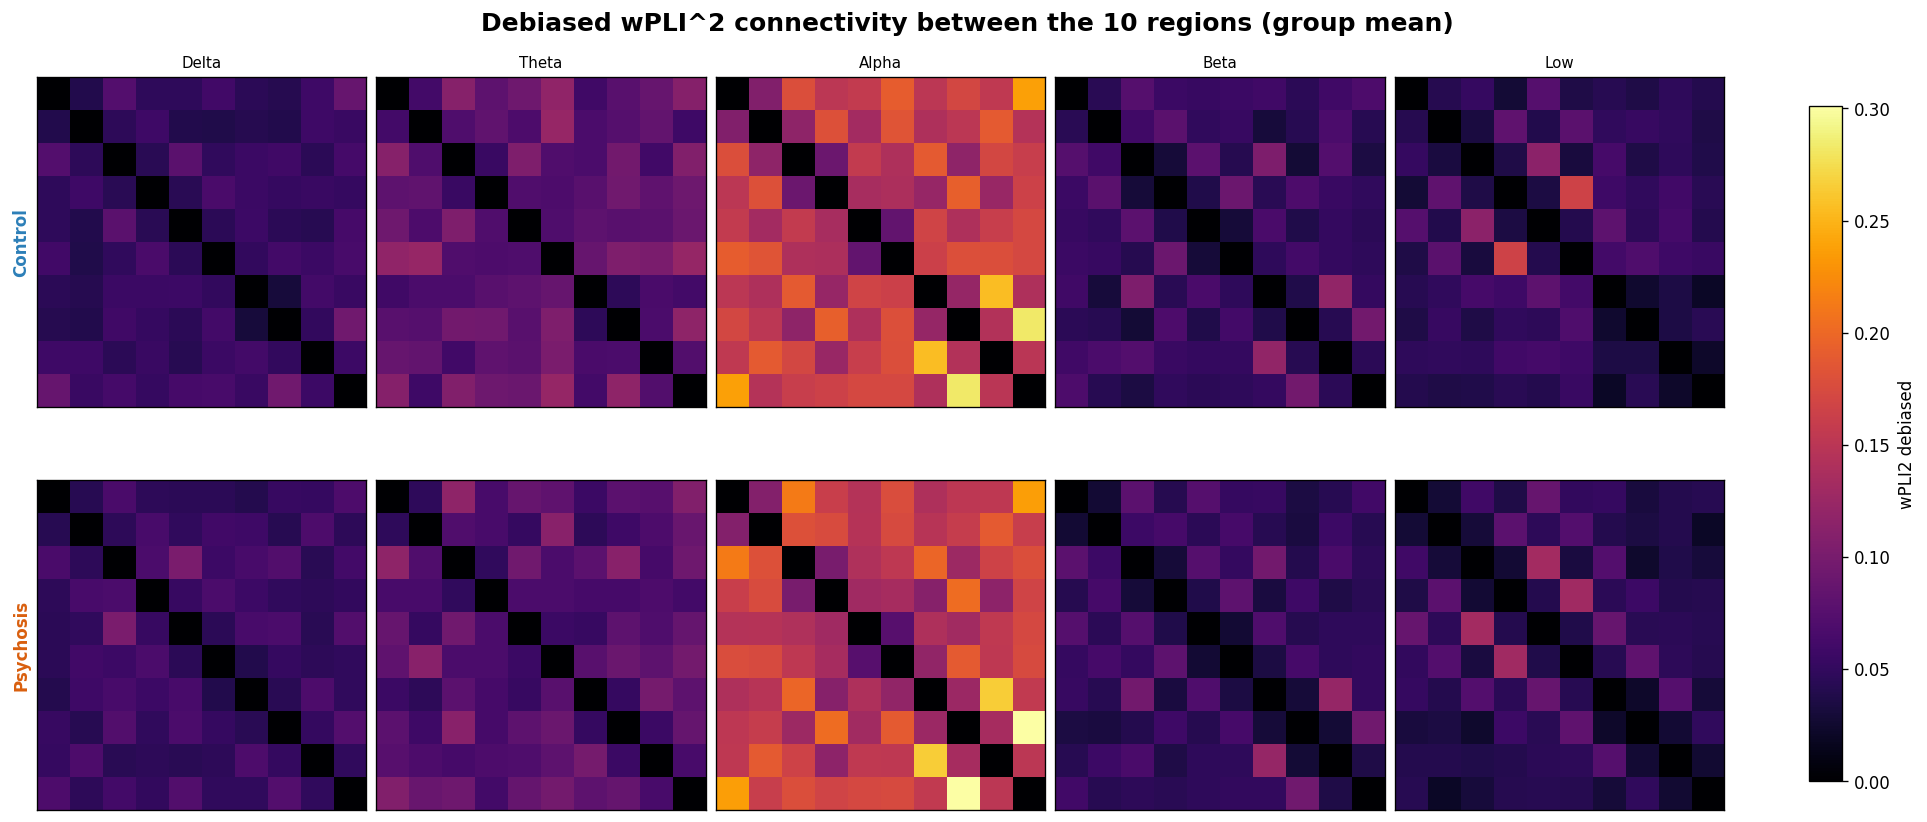

In [8]:
fig = V.fig_connectivity(tables, V.load_records_cached())
show_save(fig, "05_connectivity")

## 8. Family H - Graph theory (290)

Each band's 10-node wPLI matrix is thresholded across densities 20-50 percent and metrics are integrated
as an area under the density curve: global efficiency, characteristic path length, clustering,
transitivity, modularity, assortativity, and small-world propensity (100 random surrogates), plus five
node-level metrics per region. The curves below compare the global metrics across bands and groups.

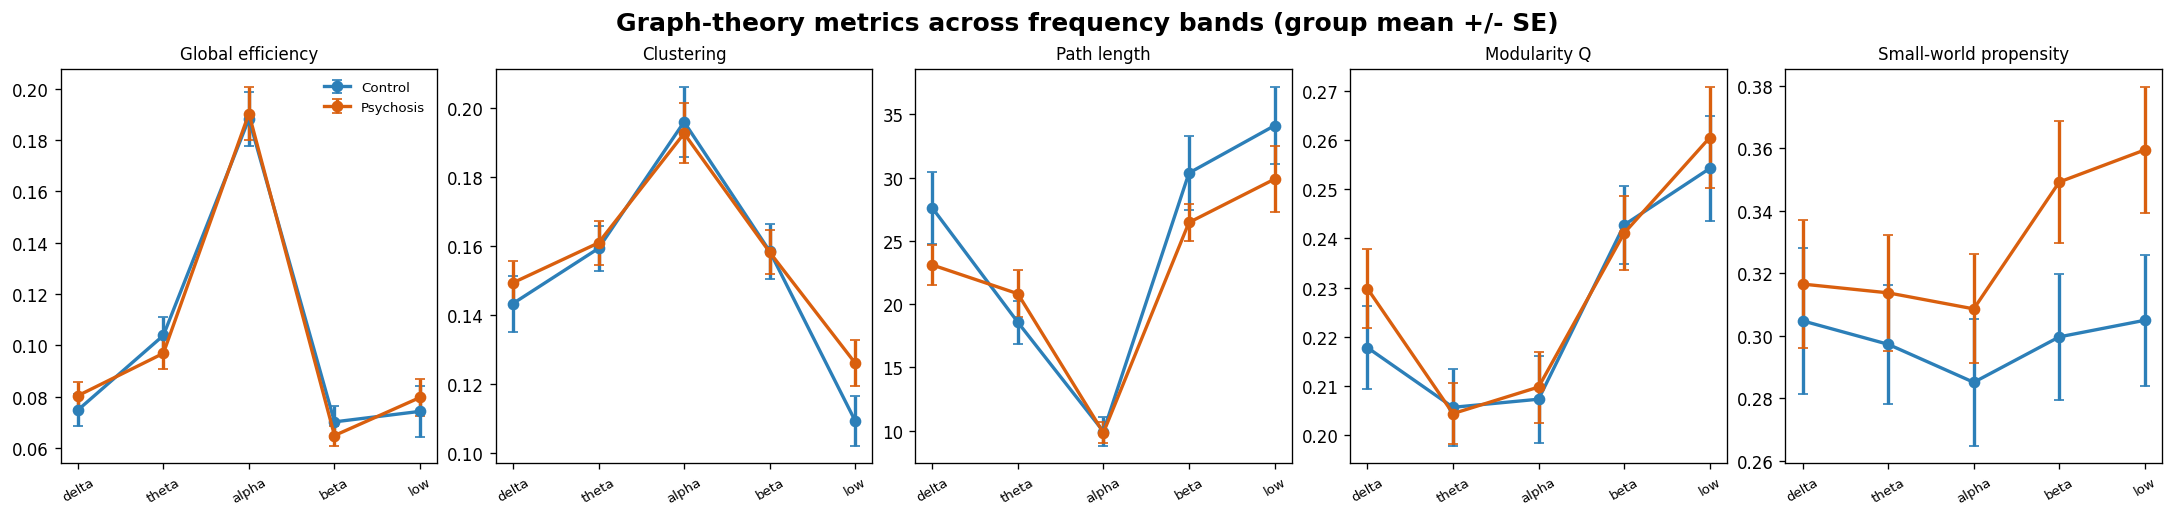

In [9]:
fig = V.fig_graph_metrics(tables)
show_save(fig, "06_graph_metrics")

## 9. Cross-family group contrast

A standardized effect size (Cohen's d, Psychosis minus Control) for every one of the 836 features,
grouped by family, with the strongest features ranked in a clean panel below so the labels do not
overlap. Points that survive the multiple-comparison correction of the next section are drawn filled and
outlined; the ranked features carry their significance stars. This is a descriptive map of where the two
groups differ most, not a classifier.

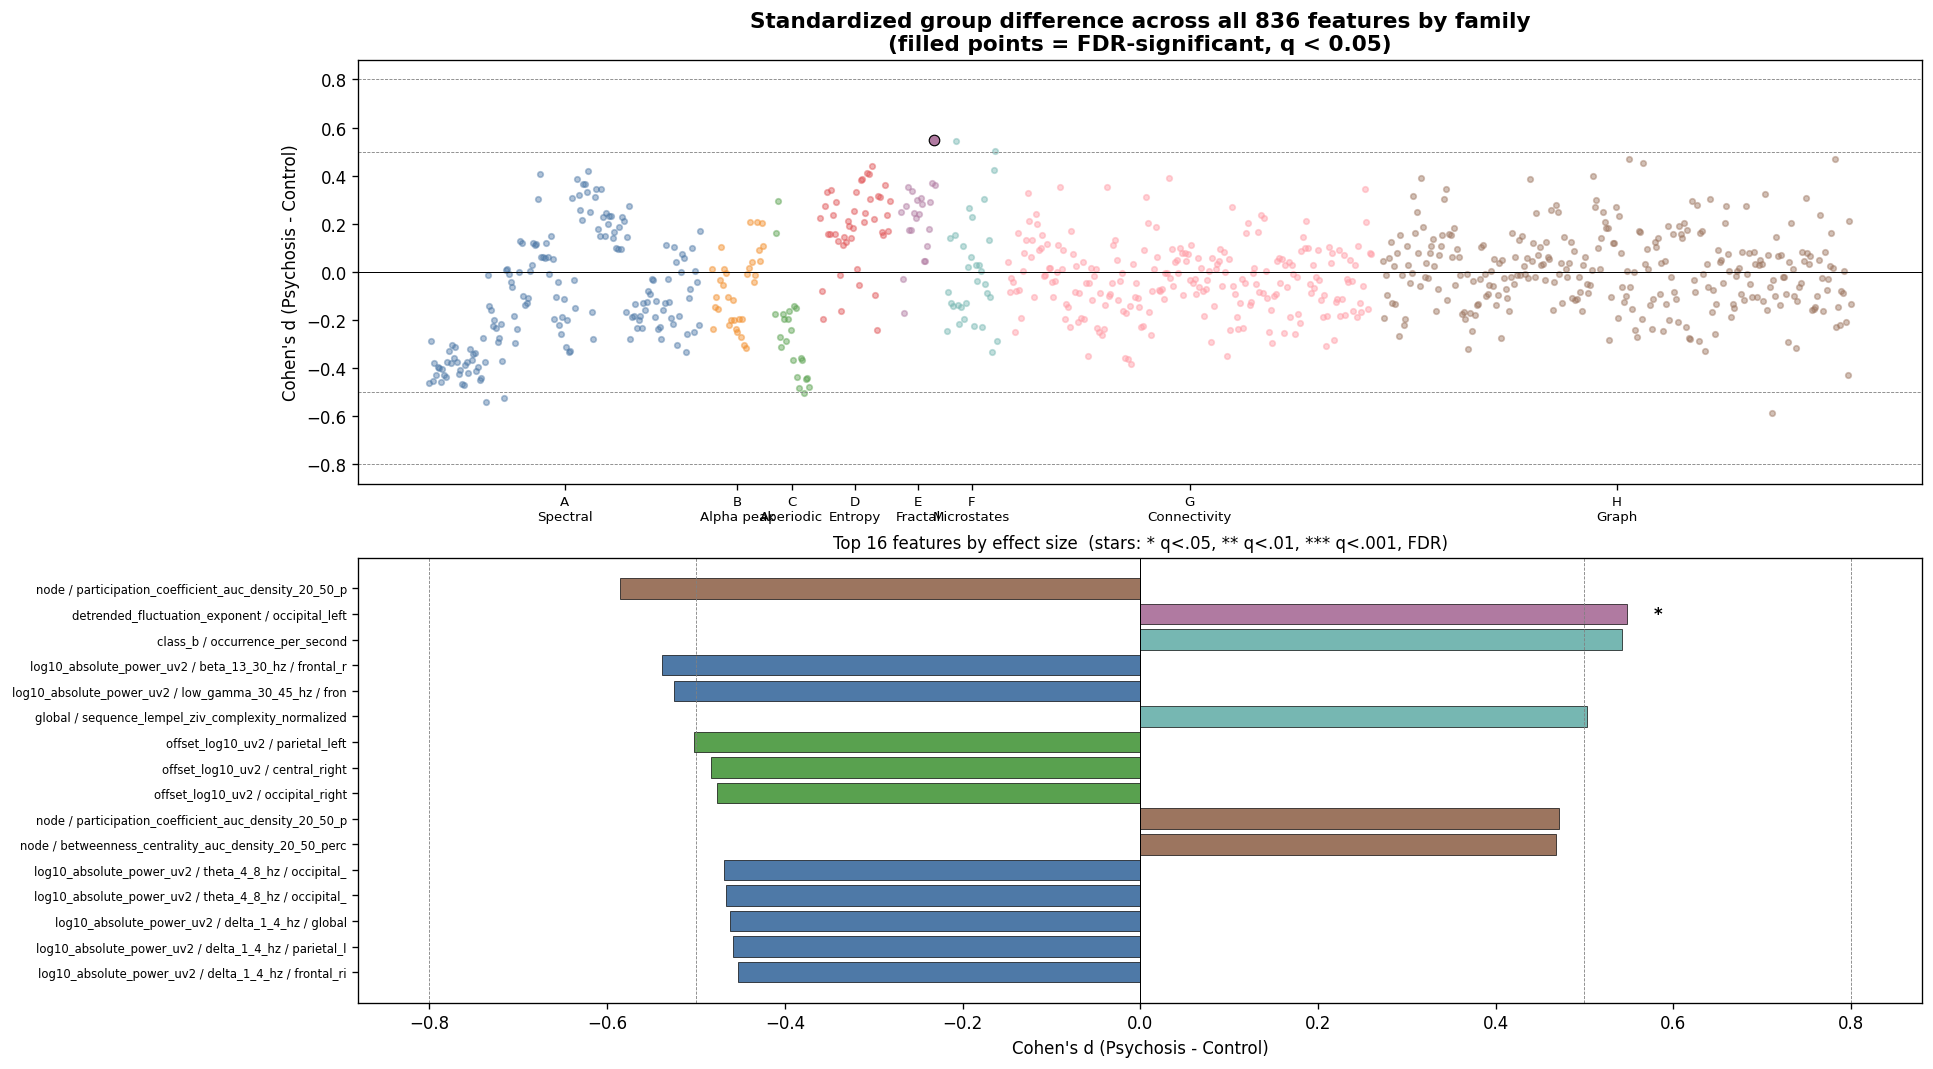

In [10]:
# Formal per-feature statistics are computed once here and reused by both figures.
stats = V.group_distribution_stats(tables, groups)
fig = V.fig_group_contrast(tables, groups, stats)
show_save(fig, "07_group_contrast")

## 10. Group distribution comparison statistics

Each feature's Control vs Psychosis distributions are compared with an automated, assumption-checked test:
Shapiro-Wilk normality is tested in each group and **only if BOTH groups are normal is a Welch t-test
used**, otherwise the non-parametric **Mann-Whitney U** rank test (a non-normal feature is never given a
t-test). The effect size is Cohen's d (Psychosis minus Control).

The analysis runs at **two levels**:

1. **Broad exploratory sweep** (all 836 features): Benjamini-Hochberg FDR **within each feature family**.
   A descriptive map of where the groups differ; at this sample size few individual sensor features
   survive family FDR, which is expected and not the primary read.
2. **Pre-specified psychosis-signature panel** (the primary analysis): a broad, theory-driven panel of
   50+ individual features (one per "neural entity", i.e. a band x region x measure) covering every
   well-replicated psychosis resting-EEG signature - posterior alpha deficit, frontal/global slow-wave
   excess, spectral and alpha-peak slowing, aperiodic slope, signal complexity/entropy, fractal dynamics,
   microstate coverage, and graph organisation. Because these are many correlated a-priori hypotheses, a
   whole-panel FDR would inflate every q past significance and hide the real effects, so the panel is read
   on **nominal (uncorrected) p < 0.05** (the FDR q is still reported as a column). The strongest,
   consistently-directioned hits are the classic posterior alpha deficit and slow-wave excess.

This is an exploratory sensor-space contrast at a modest sample size, not a clinical test.

In [ ]:
# --- Level 1: broad exploratory sweep (all 836 features, within-family FDR) ---
tested = int(stats["p"].notna().sum())
print(f"Exploratory sweep: {tested}/836 features tested "
      f"({int((stats['test']=='Welch t').sum())} Welch t, {int((stats['test']=='Mann-Whitney U').sum())} Mann-Whitney U)")
print(f"  raw p < 0.05: {int((stats['p'] < 0.05).sum())}    "
      f"within-family FDR q < 0.05: {int(stats['significant'].sum())}")

fig = V.fig_group_stats_overview(stats)
show_save(fig, "09_group_statistics_overview")
stats.to_csv(C.RESULTS_ROOT / "group_distribution_statistics.csv", index=False)

# --- Level 2: pre-specified psychosis-signature panel (50+ features, nominal p) ---
sig_groups = V.signature_groups(names)
pstats = V.group_distribution_stats(tables, sig_groups, correction="none").dropna(subset=["p"]).copy()
n_welch = int((pstats["test"] == "Welch t").sum()); n_mw = int((pstats["test"] == "Mann-Whitney U").sum())
print(f"\nSignature panel: {len(pstats)} pre-specified features "
      f"({n_welch} Welch t on normal, {n_mw} Mann-Whitney U on non-normal).")
print(f"  nominally significant (p < 0.05): {int(pstats['nominal'].sum())} features "
      f"across {pstats.loc[pstats['nominal'],'family'].nunique()} families.")

cols = ["family", "feature", "test", "cohens_d", "median_control", "median_psychosis", "p", "q"]
top = pstats.sort_values("p")[cols].head(20).copy()
top["feature"] = top["feature"].str.split("__", n=1).str[1].str.slice(0, 44)
top["cohens_d"] = top["cohens_d"].round(2); top[["p", "q"]] = top[["p", "q"]].round(4)
print("\nTop signature hits (Psychosis minus Control, ranked by p):")
print(top.to_string(index=False))
pstats.to_csv(C.RESULTS_ROOT / "signature_panel_statistics.csv", index=False)

### 10.1 Distributions of the strongest signatures

The Control vs Psychosis distributions of the strongest nominally-significant signature features (smallest
p, largest effect), as histograms with a fitted kernel-density smooth and the group medians. The posterior
alpha deficit, slow-wave excess and raised posterior entropy are the clearest separations, consistent with
the classic resting-EEG psychosis literature.

In [ ]:
# Distributions of the strongest nominally-significant signature features.
fig = V.fig_significant_distributions(tables, pstats, n=6)
show_save(fig, "10_significant_distributions")

## 11. Representative psychosis subject

One eligible psychosis recording closest to the psychosis z-score centroid, shown across every feature
family: cleaned trace, regional spectra, band-power and 1/f topographies, an occipital FOOOF fit, the
four microstate template maps with this subject's coverage, the alpha connectivity matrix, node strength,
and the microstate profile. This single dashboard replaces the previous per-subject figure dump.

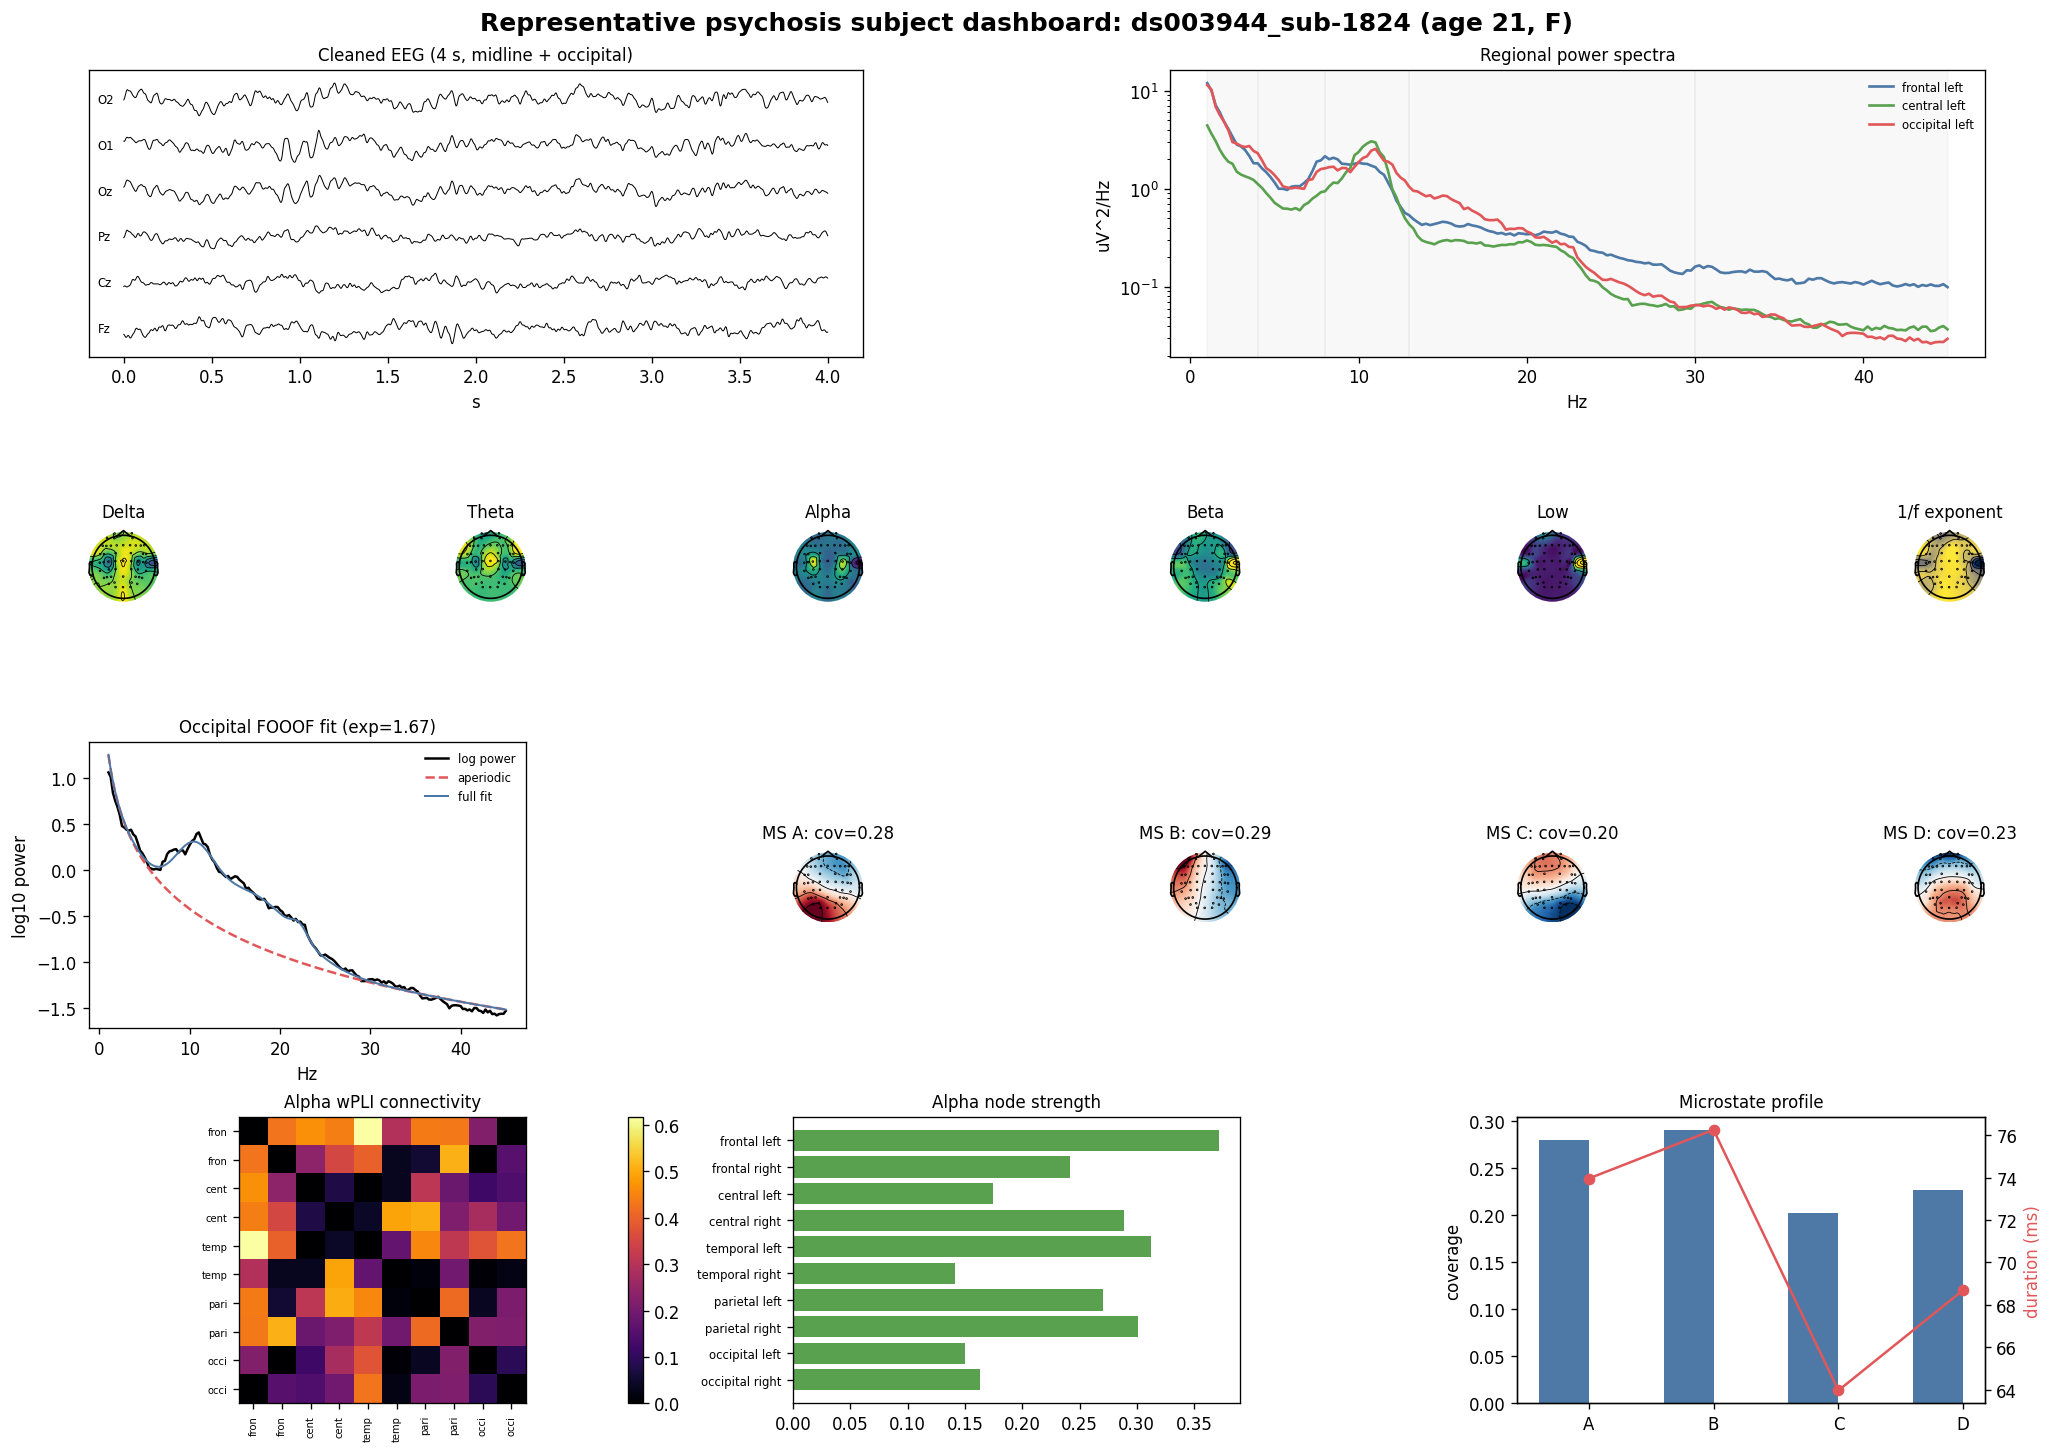

representative psychosis subject: ds003944_sub-1824


In [13]:
fig, rid = V.build_example_dashboard(save=True)
plt.show()
print("representative psychosis subject:", rid)

## 12. Non-EEG phenotypes and clinical targets

Alongside the EEG features, `results/non_eeg_features.csv` harmonizes all non-neural data across both
datasets: identifiers, 9 covariates (demographics, Hollingshead socio-economic status, chlorpromazine
equivalent), and 235 clinical phenotype targets (BPRS, SANS, SAPS, GAF/GAS, SFS, MATRICS, WASI) on the
right. These targets drive the prediction ladder in notebook 03.

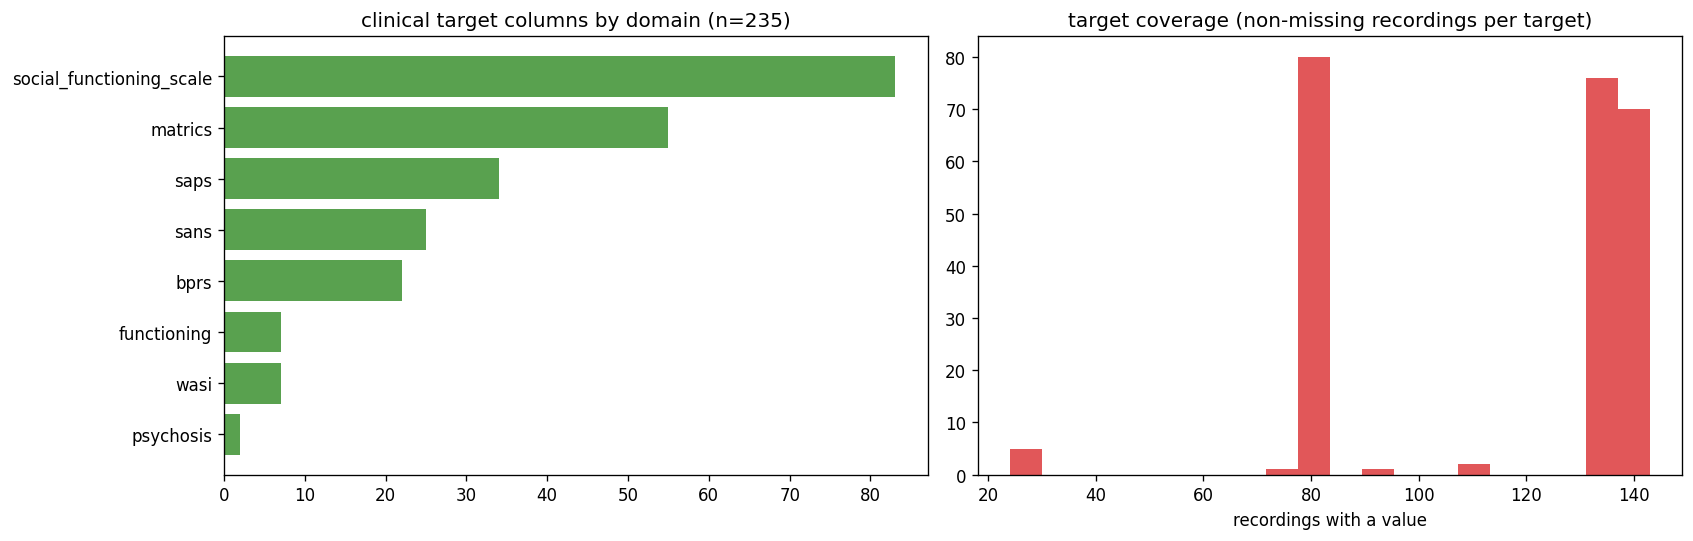

non-EEG table: (143, 247) | 9 covariates, 235 targets


In [14]:
non_eeg = tables["non_eeg"]
cov = [c for c in non_eeg.columns if c.startswith("covariate__")]
tgt = [c for c in non_eeg.columns if c.startswith("target__")]
domains = pd.Series([t.split("__")[1] for t in tgt]).value_counts()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), constrained_layout=True)
ax[0].barh(domains.index[::-1], domains.values[::-1], color="#59a14f")
ax[0].set_title(f"clinical target columns by domain (n={len(tgt)})")
cover = non_eeg[tgt].notna().sum(0).sort_values()
ax[1].hist(cover, bins=20, color="#e15759")
ax[1].set_title("target coverage (non-missing recordings per target)")
ax[1].set_xlabel("recordings with a value")
show_save(fig, "08_non_eeg_overview")
print(f"non-EEG table: {non_eeg.shape} | {len(cov)} covariates, {len(tgt)} targets")

## 13. Outputs

- `results/eeg_features.csv` - 836 raw features per recording
- `results/eeg_features_zscores.csv` - age/sex control-referenced z-scores
- `results/non_eeg_features.csv` and `results/non_eeg_feature_dictionary.csv`
- `results/group_distribution_statistics.csv` - per-feature Control vs Psychosis test, effect and FDR q
- `results/figures/cohort/*.png` and `results/figures/example_subject/*.png`

In [15]:
import glob
figs = sorted(glob.glob(str(C.FIGURE_ROOT / "**" / "*.png"), recursive=True))
print(f"figures written: {len(figs)}")
val = json.loads((C.RESULTS_ROOT / "feature_extraction_validation.json").read_text())
print(json.dumps(val, indent=2))
assert tables["eeg"].shape[1] - 1 == 836
print("\nStage 2 complete. Proceed to 03_ONTOLOGY_AND_COMPASS_LADDER.ipynb")

figures written: 13
{
  "recording_count": 143,
  "feature_count": 836,
  "finite_cells": 110229,
  "missing_cells": 9319,
  "all_nan_rows": 9,
  "complete_subjects": 134,
  "elapsed_s": 7139.5
}

Stage 2 complete. Proceed to 03_ONTOLOGY_AND_COMPASS_LADDER.ipynb
